# 05_train_final_model.ipynb
Entrenar y guardar el modelo final XGBoost usando los mejores hiperparámetros de Optuna.
- Crea un holdout para evaluación final (10%).
- Reentrena el modelo con el resto de los datos y los mejores `best_params`.
- Guarda el modelo en `models/` y métricas en `results/`.


# Celda 2 — Imports y paths (Código)

In [1]:
import os, json, time, joblib
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# Rutas (ajusta si hace falta)
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
MODELS_DIR = os.path.join(BASE_DIR, "models")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

RANDOM_SEED = 42


# Celda 3 — Cargar embeddings, etiquetas y best_params (Código)

In [2]:
# Carga de embeddings y etiquetas (asumo que guardaste un joblib antes)
# Ajusta el nombre si tu archivo tiene otro nombre
embeddings_path = os.path.join(MODELS_DIR, "embeddings.joblib")   # o donde lo guardaste
data = joblib.load(embeddings_path)
X = data["embeddings"]    # (N, D)
y = data["y"]
class_names = data.get("class_names", None)

print("Loaded X:", X.shape, "y:", y.shape, "classes:", len(np.unique(y)))

# LabelEncoder (si aún no lo tienes guardado)
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Carga best params guardados por Optuna
best_params_path = os.path.join(RESULTS_DIR, "optuna_precomputed_best.json")
if not os.path.exists(best_params_path):
    # fallback path
    best_params_path = os.path.join(RESULTS_DIR, "optuna_precomputed_best.json")

with open(best_params_path, "r") as f:
    best_params = json.load(f)

print("Loaded best_params keys:", list(best_params.keys()))


Loaded X: (20760, 512) y: (20760,) classes: 21
Loaded best_params keys: ['best_value', 'best_params']


# Celda 4 — Crear holdout final (10%) (Código)

In [3]:
# Reservamos un holdout final limpio para evaluación (no usado en Optuna)
X_train_full, X_holdout, y_train_full, y_holdout = train_test_split(
    X, y_enc, test_size=0.10, stratify=y_enc, random_state=RANDOM_SEED
)

print("Train full:", X_train_full.shape, "Holdout:", X_holdout.shape)


Train full: (18684, 512) Holdout: (2076, 512)


# Celda 5 — Preparar parámetros para xgb.train (Código)

In [4]:
# Preparamos params para xgb.train.
# best_params puede contener "n_estimators"; lo separamos.
params = best_params.copy()

# Extraer num_boost_round si existe y quitarlo del dict que pasaremos a xgb.train
num_boost_round = int(params.pop("n_estimators", 200))

# Asegurar keys obligatorias para xgb.train
params.update({
    "objective": "multi:softprob",
    "num_class": int(len(np.unique(y_enc))),
    "eval_metric": "mlogloss",
    # usa GPU si está disponible: device='cuda' (tu entorno lo soporta)
    "tree_method": "hist",
    "device": "cuda",   # si tu build no soporta GPU esto fallará -> cambia a "cpu"
    "verbosity": 0
})

print("Final train params preview:", {k: params[k] for k in ("objective","num_class","eta","max_depth") if k in params})
print("num_boost_round:", num_boost_round)


Final train params preview: {'objective': 'multi:softprob', 'num_class': 21}
num_boost_round: 200


# Celda 6 — Entrenar modelo final (sobre X_train_full) con validación interna (early stopping) (Código)

In [5]:
# Convertir a DMatrix
dtrain_full = xgb.DMatrix(X_train_full, label=y_train_full)
dholdout = xgb.DMatrix(X_holdout, label=y_holdout)

# Entrenamiento con early stopping usando una porción de validación dentro de train_full
# (opcionalmente podemos usar un small split interno; aquí usamos holdout sólo para evaluación final)
t0 = time.time()
bst = xgb.train(
    params=params,
    dtrain=dtrain_full,
    num_boost_round=num_boost_round,
    evals=[(dtrain_full, "train"), (dholdout, "holdout_eval")],
    early_stopping_rounds=30,
    verbose_eval=10
)
t1 = time.time()
print("Training finished in", round(t1-t0,1), "s")
print("Best iteration:", bst.best_iteration)


[0]	train-mlogloss:2.40504	holdout_eval-mlogloss:2.66990
[10]	train-mlogloss:0.83464	holdout_eval-mlogloss:1.94771
[20]	train-mlogloss:0.37865	holdout_eval-mlogloss:1.75253
[30]	train-mlogloss:0.19230	holdout_eval-mlogloss:1.66998
[40]	train-mlogloss:0.10574	holdout_eval-mlogloss:1.61864
[50]	train-mlogloss:0.06006	holdout_eval-mlogloss:1.58638
[60]	train-mlogloss:0.03696	holdout_eval-mlogloss:1.56789
[70]	train-mlogloss:0.02423	holdout_eval-mlogloss:1.55675
[80]	train-mlogloss:0.01699	holdout_eval-mlogloss:1.54823
[90]	train-mlogloss:0.01268	holdout_eval-mlogloss:1.53564
[100]	train-mlogloss:0.00996	holdout_eval-mlogloss:1.53158
[110]	train-mlogloss:0.00814	holdout_eval-mlogloss:1.52816
[120]	train-mlogloss:0.00687	holdout_eval-mlogloss:1.52432
[130]	train-mlogloss:0.00594	holdout_eval-mlogloss:1.52346
[140]	train-mlogloss:0.00524	holdout_eval-mlogloss:1.52099
[150]	train-mlogloss:0.00470	holdout_eval-mlogloss:1.52377
[160]	train-mlogloss:0.00427	holdout_eval-mlogloss:1.52505
[170]	tr

# Celda 7 — Evaluación en holdout y métricas (Código)

Holdout accuracy: 0.5515414258188824
Classification report (text):
              precision    recall  f1-score   support

           0       0.39      0.30      0.34        98
           1       0.68      0.68      0.68        97
           2       0.38      0.38      0.38        97
           3       0.67      0.55      0.60        98
           4       0.58      0.61      0.60        98
           5       0.54      0.53      0.54        98
           6       0.42      0.37      0.39        98
           7       0.60      0.56      0.58       100
           8       0.72      0.80      0.75        98
           9       0.63      0.69      0.66        98
          10       0.55      0.57      0.56        98
          11       0.67      0.69      0.68        98
          12       0.61      0.65      0.63       100
          13       0.61      0.71      0.66       100
          14       0.47      0.41      0.44       100
          15       0.45      0.41      0.43       100
          16  

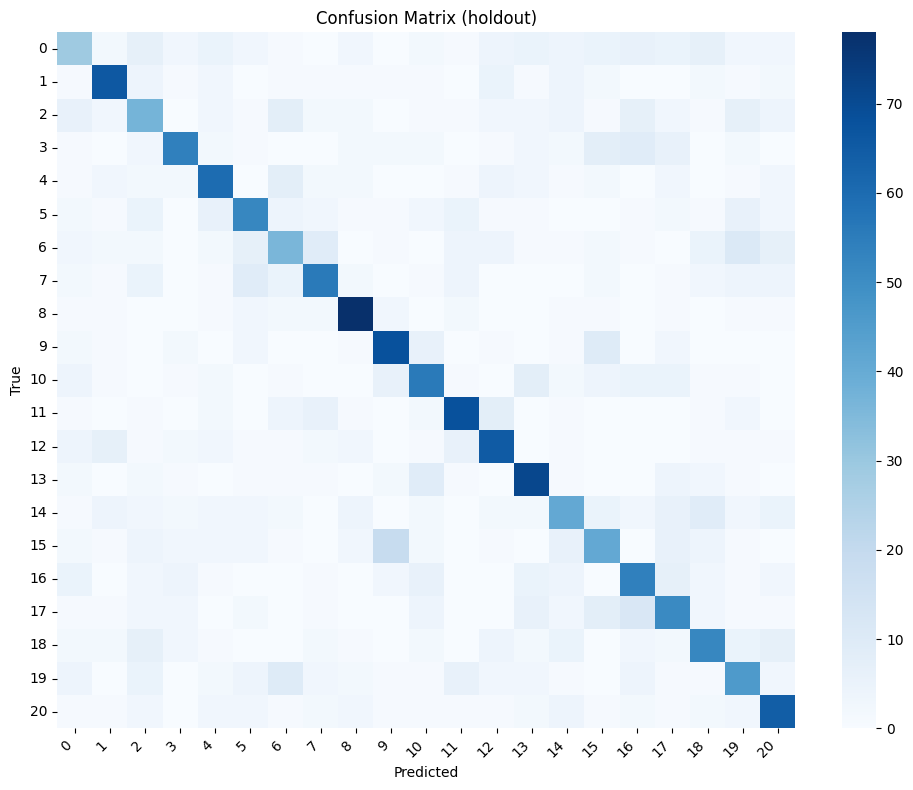

Saved confusion matrix image to c:\Users\yeder\Documents\Factoria F5 Bootcamp IA\proyecto7_ensemble_grupo2\backend\ML\results\confusion_matrix_holdout.png


In [6]:
# --- Celda 7 (CORREGIDA) — Evaluación en holdout y métricas ---
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns  # si no lo tienes instalado puedes usar matplotlib puro

# Predicción en holdout (probabilidades -> etiquetas)
preds_proba = bst.predict(dholdout)
preds = np.argmax(preds_proba, axis=1)

acc = accuracy_score(y_holdout, preds)
print("Holdout accuracy:", acc)

# Preparar nombres de clase como strings (evita TypeError)
class_names_str = [str(c) for c in le.classes_]

# Reporte por clase (diccionario)
report = classification_report(y_holdout, preds, target_names=class_names_str, output_dict=True)
print("Classification report (text):")
print(classification_report(y_holdout, preds, target_names=class_names_str))

# Matriz de confusión
cm = confusion_matrix(y_holdout, preds)
print("Confusion matrix shape:", cm.shape)

# Guardar métricas y reporte
metrics_out = {
    "holdout_accuracy": float(acc),
    "classification_report": report,
    "best_params": best_params,
    "best_iteration": int(getattr(bst, "best_iteration", num_boost_round))
}
out_path = os.path.join(RESULTS_DIR, "final_model_metrics.json")
with open(out_path, "w") as f:
    json.dump(metrics_out, f, indent=2, ensure_ascii=False)
print(f"Saved metrics to {out_path}")

# Dibujar y guardar matriz de confusión (heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
            xticklabels=class_names_str, yticklabels=class_names_str)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (holdout)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
cm_path = os.path.join(RESULTS_DIR, "confusion_matrix_holdout.png")
plt.savefig(cm_path, dpi=200)
plt.show()
print(f"Saved confusion matrix image to {cm_path}")


# Celda 8 — Guardar modelo y artefactos (Código)

In [7]:
# Guardar booster nativo (JSON/UBJ)
model_path = os.path.join(MODELS_DIR, "xgb_final_model.json")
bst.save_model(model_path)
print("Saved XGBoost booster to:", model_path)

# También guardar como joblib wrapper (útil en Python)
joblib.dump(bst, os.path.join(MODELS_DIR, "xgb_final_bst.joblib"))
# Guardar LabelEncoder para mapear etiquetas
joblib.dump(le, os.path.join(MODELS_DIR, "label_encoder.joblib"))

print("Saved joblib artifacts in models/")


Saved XGBoost booster to: c:\Users\yeder\Documents\Factoria F5 Bootcamp IA\proyecto7_ensemble_grupo2\backend\ML\models\xgb_final_model.json
Saved joblib artifacts in models/


# Celda 9 — Feature importance y gráficas (Código)

<Figure size 1000x800 with 0 Axes>

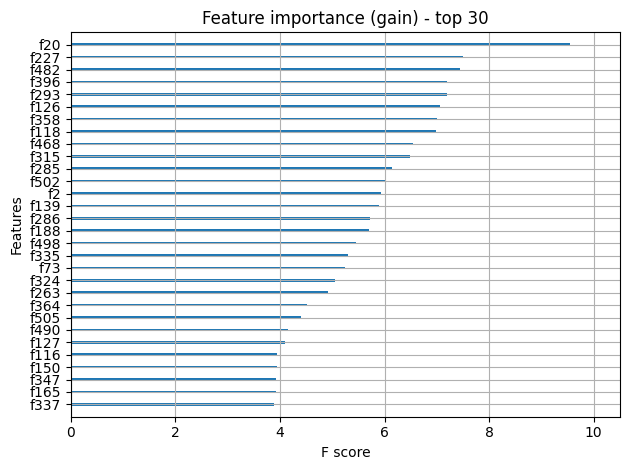

Saved feature importance to results/feature_importance_top30.png


In [8]:
# Feature importance (gain)
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(10,8))
plot_importance(bst, importance_type='gain', max_num_features=30, show_values=False)
plt.title("Feature importance (gain) - top 30")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "feature_importance_top30.png"))
plt.show()
print("Saved feature importance to results/feature_importance_top30.png")


# Celda 10 — Función de inferencia rápida (Código)

In [9]:
# Función que recibe un embedding (vector 1D) y devuelve etiqueta + probas
import numpy as np

def predict_from_embedding(embedding: np.ndarray, bst_model_path=model_path, label_encoder_path=os.path.join(MODELS_DIR, "label_encoder.joblib")):
    # embedding: shape (D,) o (1, D)
    if embedding.ndim == 1:
        embedding = embedding.reshape(1, -1)
    dm = xgb.DMatrix(embedding)
    bst_loaded = xgb.Booster()
    bst_loaded.load_model(bst_model_path)
    proba = bst_loaded.predict(dm)  # shape (1, num_class)
    label_idx = int(np.argmax(proba, axis=1)[0])
    le_local = joblib.load(label_encoder_path)
    label = le_local.inverse_transform([label_idx])[0]
    return {"label": label, "label_idx": label_idx, "proba": proba.tolist()[0]}

# Ejemplo:
# emb_example = X_holdout[0]
# print(predict_from_embedding(emb_example))
